# CNN Classification Malaria Data

The aim of this project is to develop a Convolutional Neural Network (CNN) to automatically detect malaria parasites in thin blood smear images, using Transfer Learning techniques. The project aims to achieve high diagnostic accuracy (95%+) and to compare the performance of a custom-built CNN model with state-of-the-art pre-trained models such as VGG16, VGG19, and ResNet50.

<img src='https://cdn.t3pedia.org/media/uploads/2025/05/15/hOi6FyeSFoQgp7BYBPFpo8Fa0okqwqlB.png' width='750'>

In [30]:
import cv2
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D,Dense, Flatten, Input, MaxPooling2D, Dropout, BatchNormalization, Reshape
import os

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.applications import VGG16, VGG19, ResNet50
import warnings
warnings.filterwarnings('ignore')

In [31]:
ls

 Volume in drive C is OS
 Volume Serial Number is A4B6-F5AB

 Directory of C:\Users\furka\Documents\yapay zeka\odevler\Image Classification with CNN for Malaria Data

07/31/2026  11:00 PM    <DIR>          .
07/29/2026  04:08 PM    <DIR>          ..
07/28/2026  08:27 PM    <DIR>          .ipynb_checkpoints
07/31/2026  03:51 PM               790 app.py
07/28/2026  08:22 PM       708,172,590 archive.zip
07/31/2026  11:00 PM           203,220 CNN_Malaria_Data.ipynb
07/28/2026  09:03 PM    <DIR>          Malaria
07/29/2026  03:08 PM       367,255,947 malaria_data.TL.keras
07/28/2026  11:28 PM        88,748,632 malaria_detection_model.h5
               5 File(s)  1,164,381,179 bytes
               4 Dir(s)  719,814,021,120 bytes free


In [32]:
labels=['Parasitized','Uninfected']
img_path='Malaria/'

In [33]:
img_list = []
label_list = []          
for label in labels:
    full_path = os.path.join(img_path, label) 
    for img_file in os.listdir(full_path):
        if img_file.endswith(('.png', '.jpg', '.jpeg')):
            img_list.append(os.path.join(full_path, img_file))
            label_list.append(label)        

In [34]:
df=pd.DataFrame({'img':img_list,'label':label_list})

In [35]:
df

,img,label
0,Malaria/Parasitized\C100P61ThinF_IMG_20150918_...,Parasitized
1,Malaria/Parasitized\C100P61ThinF_IMG_20150918_...,Parasitized
2,Malaria/Parasitized\C100P61ThinF_IMG_20150918_...,Parasitized
3,Malaria/Parasitized\C100P61ThinF_IMG_20150918_...,Parasitized
4,Malaria/Parasitized\C100P61ThinF_IMG_20150918_...,Parasitized
...,...,...
27553,Malaria/Uninfected\C99P60ThinF_IMG_20150918_14...,Uninfected
27554,Malaria/Uninfected\C99P60ThinF_IMG_20150918_14...,Uninfected
27555,Malaria/Uninfected\C99P60ThinF_IMG_20150918_14...,Uninfected
27556,Malaria/Uninfected\C99P60ThinF_IMG_20150918_14...,Uninfected


In [36]:
d=({'Parasitized':1, 'Uninfected':0})
df['label_encoded']=df['label'].map(d)

In [37]:
df

,img,label,label_encoded
0,Malaria/Parasitized\C100P61ThinF_IMG_20150918_...,Parasitized,1
1,Malaria/Parasitized\C100P61ThinF_IMG_20150918_...,Parasitized,1
2,Malaria/Parasitized\C100P61ThinF_IMG_20150918_...,Parasitized,1
3,Malaria/Parasitized\C100P61ThinF_IMG_20150918_...,Parasitized,1
4,Malaria/Parasitized\C100P61ThinF_IMG_20150918_...,Parasitized,1
...,...,...,...
27553,Malaria/Uninfected\C99P60ThinF_IMG_20150918_14...,Uninfected,0
27554,Malaria/Uninfected\C99P60ThinF_IMG_20150918_14...,Uninfected,0
27555,Malaria/Uninfected\C99P60ThinF_IMG_20150918_14...,Uninfected,0
27556,Malaria/Uninfected\C99P60ThinF_IMG_20150918_14...,Uninfected,0


In [38]:
df.sample(10)

,img,label,label_encoded
770,Malaria/Parasitized\C116P77ThinF_IMG_20150930_...,Parasitized,1
21367,Malaria/Uninfected\C218ThinF_IMG_20151106_1442...,Uninfected,0
26721,Malaria/Uninfected\C87P48ThinF_IMG_20150820_14...,Uninfected,0
1896,Malaria/Parasitized\C126P87ThinF_IMG_20151004_...,Parasitized,1
13390,Malaria/Parasitized\C99P60ThinF_IMG_20150918_1...,Parasitized,1
11535,Malaria/Parasitized\C79P40ThinF_IMG_20150817_1...,Parasitized,1
4731,Malaria/Parasitized\C159P120ThinF_IMG_20151115...,Parasitized,1
1182,Malaria/Parasitized\C117P78ThinF_IMG_20150930_...,Parasitized,1
2166,Malaria/Parasitized\C129P90ThinF_IMG_20151004_...,Parasitized,1
3728,Malaria/Parasitized\C136P97ThinF_IMG_20151005_...,Parasitized,1


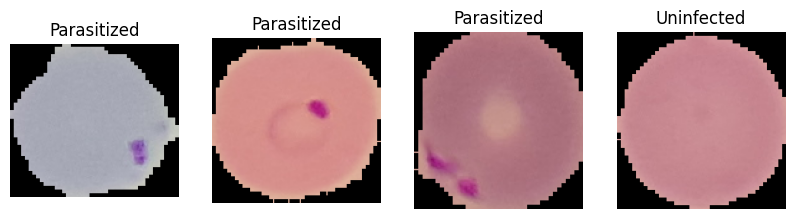

In [39]:
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    sample = df.sample(1)
    img = cv2.imread(sample['img'].values[0])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(sample['label'].values[0])
    plt.axis('off')
plt.show()

In [41]:
print(df['label'].value_counts())

label
Parasitized    13779
Uninfected     13779
Name: count, dtype: int64


Text(0, 0.5, 'Count')

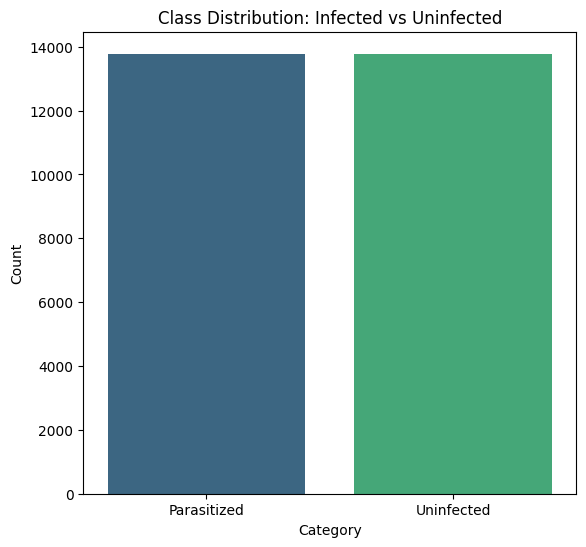

In [42]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(x=counts.index, y=counts.values, palette='viridis')
plt.title('Class Distribution: Infected vs Uninfected')
plt.xlabel('Category')
plt.ylabel('Count')

In [13]:
import cv2
import os
import glob

x = []
y = [] 

#
klasorler = {
    'Parasitized': 'Malaria/Parasitized',
    'Uninfected': 'Malaria/Uninfected'
}

#
uzantilar = ('*.jpg', '*.jpeg', '*.png', '*.bmp')

for etiket, klasor_yolu in klasorler.items():
    print(f"🔄 {klasor_yolu} klasöründeki resimler yükleniyor...")
    
    # Klasörün içindeki tüm resim dosyalarını bul
    resim_listesi = []
    for uzanti in uzantilar:
        resim_listesi.extend(glob.glob(os.path.join(klasor_yolu, uzanti)))
        
    if len(resim_listesi) == 0:
        print(f"⚠️ Uyarı: {klasor_yolu} içinde hiç resim bulunamadı! Klasör yolunu kontrol et.")
        continue

    for img_path in resim_listesi:
        img = cv2.imread(img_path)
        
        if img is None:
            print(f"❌ Okunamayan bozuk resim atlandı: {img_path}")
            continue
            
        # Görsel işleme adımları
        img = cv2.resize(img, (128, 128))
        img = img / 255.0  # Normalize et
        
        x.append(img)
        # Parazit için 1, Un_Parazit için 0 etiketini atayalım (Model eğitimi için gerekir)
        y.append(1 if etiket == 'Parasitized' else 0)

print(f"\n✅ İşlem başarıyla tamamlandı!")
print(f"📊 Toplam yüklenen resim sayısı: {len(x)}")

🔄 Malaria/Parasitized klasöründeki resimler yükleniyor...
🔄 Malaria/Uninfected klasöründeki resimler yükleniyor...

✅ İşlem başarıyla tamamlandı!
📊 Toplam yüklenen resim sayısı: 27558


In [14]:
x=np.array(x)

In [15]:
x.shape

(27558, 128, 128, 3)

In [16]:
y=df[['label_encoded']]

In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.20, random_state=42) #random_state=42 seed

In [18]:
y_train=np.array(y_train,dtype=np.int32)
y_test=np.array(y_test,dtype=np.int32)

In [19]:
model=Sequential()
model.add(Input(shape=(128, 128, 3)))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))  # Added activation function
model.add(Dense(1, activation='sigmoid'))  # Ensure 2 classes for binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [20]:
history=model.fit(x_train,y_train,validation_data=(x_test,y_test), epochs=15,batch_size=16, verbose=1)

Epoch 1/15
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 188s 135ms/step - accuracy: 0.8108 - loss: 0.3978 - val_accuracy: 0.9267 - val_loss: 0.2265
Epoch 2/15
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 170s 124ms/step - accuracy: 0.9334 - loss: 0.1921 - val_accuracy: 0.9434 - val_loss: 0.1755
Epoch 3/15
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 171s 124ms/step - accuracy: 0.9450 - loss: 0.1624 - val_accuracy: 0.9410 - val_loss: 0.1897
Epoch 4/15
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 171s 124ms/step - accuracy: 0.9562 - loss: 0.1249 - val_accuracy: 0.9458 - val_loss: 0.1764
Epoch 5/15
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 166s 120ms/step - accuracy: 0.9668 - loss: 0.0950 - val_accuracy: 0.9361 - val_loss: 0.1906
Epoch 6/15
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 162s 117ms/step - accuracy: 0.9751 - loss: 0.0672 - val_accuracy: 0.9321 - val_loss: 0.3210
Epoch 7/15
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 161s 117ms/step - accuracy: 0.9828 - loss: 0.0481 - val_accuracy: 0.9298 - val_loss: 0.2549
Epoch 8/15
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 166s 120ms/step - ac

In [21]:
model.save('malaria_detection_model.h5')

## Transfer Learning

In [22]:
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [23]:
data_dir='Malaria'
img_width,img_heigth=224,224
train_datagen=ImageDataGenerator(rescale=1/255, validation_split=0.20)
train_datagenerator=train_datagen.flow_from_directory(directory=data_dir,target_size=(img_width,img_heigth),
                                class_mode='binary', subset='training')
test_datagen=ImageDataGenerator(rescale=1/255)
test_datagenerator=train_datagen.flow_from_directory(directory=data_dir,target_size=(img_width,img_heigth),
                                class_mode='binary', subset='validation')

base_model=VGG16(weights='imagenet', input_shape=(img_width,img_heigth,3), include_top=False)

model=Sequential()
model.add(base_model)
for layer in base_model.layers:
    layer.trainable=False

model.add(Flatten())
model.add(Dense(1024,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

model.fit(train_datagenerator,epochs=10,validation_data=test_datagenerator)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 1806s 3s/step - accuracy: 0.8804 - loss: 0.3429 - val_accuracy: 0.9187 - val_loss: 0.2026
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 1770s 3s/step - accuracy: 0.9322 - loss: 0.1806 - val_accuracy: 0.9089 - val_loss: 0.2235
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 1775s 3s/step - accuracy: 0.9363 - loss: 0.1700 - val_accuracy: 0.9278 - val_loss: 0.1786
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 1776s 3s/step - accuracy: 0.9451 - loss: 0.1474 - val_accuracy: 0.9250 - val_loss: 0.1815
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 1766s 3s/step - accuracy: 0.9478 - loss: 0.1381 - val_accuracy: 0.9260 - val_loss: 0.1876
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 1772s 3s/step - accuracy: 0.9502 - loss: 0.1345 - val_accuracy: 0.9319 - val_loss: 0.1823
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 1766s 3s/step - accuracy: 0.9575 - loss: 0.1161 - val_accuracy: 0.9265 - val_loss: 0.1836
Epoch

In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1024)                │      25,691,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │           1,025 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 91,791,173 (350.16 MB)

 Trainable params: 25,692,161 (98.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 51,384,324 (196.02 MB)

In [29]:
model.save('malaria_data.TL.keras')

In this project, we built a deep learning classification model using nearly 30,000 images of malaria-infected and uninfected cells to detect which ones are infected with malaria and which are not. Then we applied transfer learning, leveraging pre-trained models that have learned from millions of images, and used them to make predictions.